# Multi-Asset Market Stress Monitoring — Integrated Project Pipeline
Stages 4–13 are executed here; Stages 14–16 are documented in `docs/`. The model estimates next-day high-stress probability for analyst review, not trading.

In [1]:
from pathlib import Path
import os,sys,subprocess,time
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
P=Path.cwd().resolve(); P=P.parent if P.name=='notebooks' else (P/'project' if (P/'project').is_dir() else P)
sys.path.insert(0,str(P))
from src.eda import eda_summary
from src.evaluation import bootstrap_accuracy,metrics
from src.features import FEATURES,build_market_features
from src.modeling import train_time_split,save_bundle
from src.outliers import detect_outliers_iqr,winsorize_series
DATA=P/'data'; REPORTS=P/'reports'; IMAGES=REPORTS/'images'; IMAGES.mkdir(parents=True,exist_ok=True)
print('Project root:',P)

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/zhanyadan/Desktop/bootcamp_Yadan_Zhan/project


## Stages 4–6: Load validated processed data
The immutable raw acquisition is retained in `data/raw`; this pipeline starts from the Stage 6 analysis-ready adjusted closes to avoid network dependence.

In [2]:
prices=pd.read_csv(DATA/'processed/multi_asset_market_data_processed.csv',parse_dates=['Date']).sort_values('Date')
assert {'Date','SPY','VIX','TLT','GLD'}.issubset(prices.columns)
assert not prices[['SPY','VIX','TLT','GLD']].isna().any().any()
assert prices.Date.is_monotonic_increasing and not prices.Date.duplicated().any()
print('Shape:',prices.shape,'Date range:',prices.Date.min().date(),'to',prices.Date.max().date())
display(prices.head())

Shape: (1508, 5) Date range: 2020-01-02 to 2025-12-31


,Date,GLD,SPY,TLT,VIX
0,2020-01-02,143.949997,296.125244,112.431007,12.47
1,2020-01-03,145.860001,293.882843,114.162506,14.02
2,2020-01-06,147.389999,295.004150,113.514214,13.85
3,2020-01-07,147.970001,294.174652,112.956207,13.79
4,2020-01-08,146.860001,295.742523,112.209465,13.45


## Stage 7: Outlier risk and sensitivity
Market extremes may be genuine stress signals. We flag SPY return outliers and compare dispersion before/after winsorizing, but retain raw observations in the primary model.

IQR outliers: 86


,all,winsorized
mean,0.000636,0.000598
median,0.000973,0.000973
std,0.013070,0.011113
n,1507.000000,1507.000000


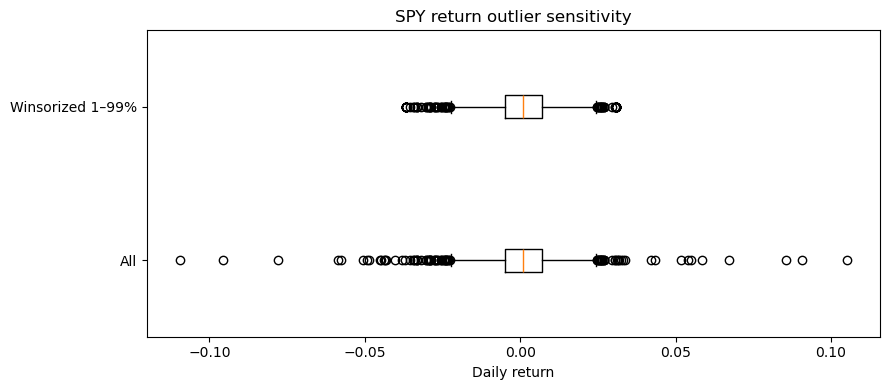

In [3]:
spy_return=prices.SPY.pct_change(); outlier=detect_outliers_iqr(spy_return,1.5); win=winsorize_series(spy_return,.01,.99)
outlier_comparison=pd.DataFrame({'all':[spy_return.mean(),spy_return.median(),spy_return.std(),spy_return.count()],'winsorized':[win.mean(),win.median(),win.std(),win.count()]},index=['mean','median','std','n']); print('IQR outliers:',int(outlier.sum())); display(outlier_comparison)
fig,ax=plt.subplots(figsize=(9,4)); ax.boxplot([spy_return.dropna(),win.dropna()],tick_labels=['All','Winsorized 1–99%'],vert=False); ax.set(title='SPY return outlier sensitivity',xlabel='Daily return'); fig.tight_layout(); fig.savefig(IMAGES/'outlier_sensitivity.png',dpi=170); plt.show()

## Stage 8: Exploratory data analysis
Price levels trend, VIX is right-skewed, and stress clusters. Returns and volatility—not raw price—are therefore used for modeling.

,count,mean,std,min,25%,50%,75%,max
GLD,1508.0,203.600398,58.318893,138.039993,167.784996,178.729996,220.392498,416.739990
SPY,1508.0,438.539876,108.429783,204.418259,367.614174,414.079712,521.100662,686.730530
TLT,1508.0,101.670587,19.944545,73.406967,84.823626,91.421001,121.042578,142.127045
VIX,1508.0,21.005630,7.902060,11.860000,15.947500,19.070000,24.110001,82.690002


,missing
Date,0
GLD,0
SPY,0
TLT,0
VIX,0


,skew,kurt
GLD,1.706648,2.130968
SPY,0.479073,-0.544857
TLT,0.553164,-1.278018
VIX,2.637217,12.021859


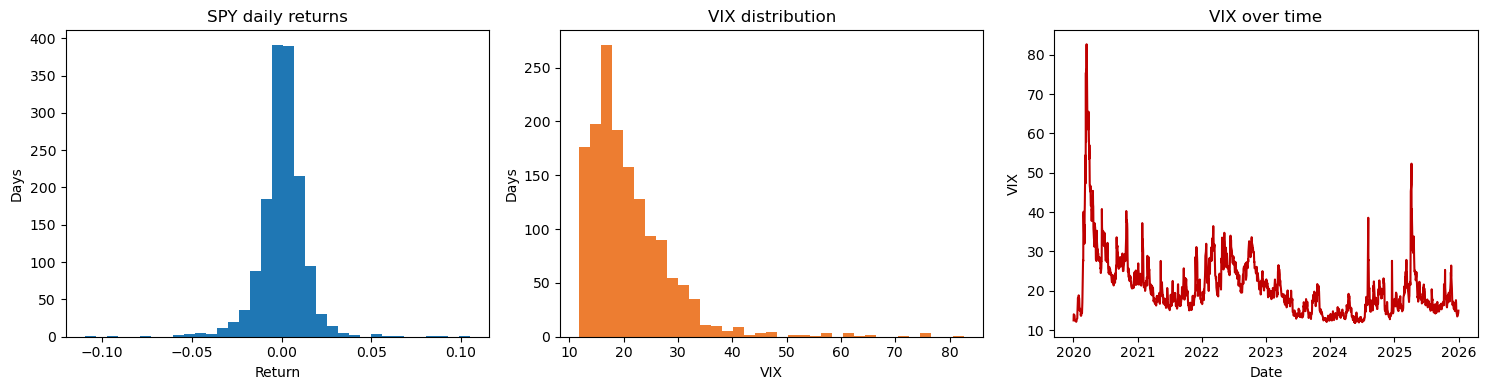

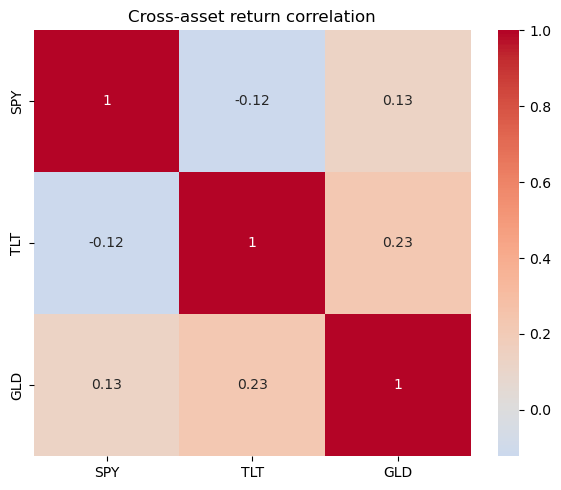

In [4]:
eda=eda_summary(prices); display(eda['numeric']); display(eda['missing']); display(eda['skew_kurt'])
returns=prices.set_index('Date')[['SPY','TLT','GLD']].pct_change(); fig,axes=plt.subplots(1,3,figsize=(15,4)); axes[0].hist(spy_return.dropna(),bins=35); axes[0].set(title='SPY daily returns',xlabel='Return',ylabel='Days'); axes[1].hist(prices.VIX,bins=35,color='#ED7D31'); axes[1].set(title='VIX distribution',xlabel='VIX',ylabel='Days'); axes[2].plot(prices.Date,prices.VIX,color='#C00000'); axes[2].set(title='VIX over time',xlabel='Date',ylabel='VIX'); fig.tight_layout(); fig.savefig(IMAGES/'eda_distributions.png',dpi=170); plt.show()
fig,ax=plt.subplots(figsize=(6,5)); sns.heatmap(returns.corr(),annot=True,cmap='coolwarm',center=0,ax=ax); ax.set_title('Cross-asset return correlation'); fig.tight_layout(); plt.show()

The time plot shows level shifts and volatility clustering rather than stable seasonality. Correlations are regime-dependent, motivating rolling and lagged features and chronological validation.

## Stage 9: Leakage-aware features
Lagged returns represent yesterday’s cross-asset move; 20-day SPY volatility captures risk regime; 60-day drawdown and VIX z-score capture level stress relative to recent history.

Feature table: (1447, 17) /Users/zhanyadan/Desktop/bootcamp_Yadan_Zhan/project/data/processed/market_features.csv


,spy_ret_lag1,vix_change_lag1,spy_vol_20,spy_drawdown,vix_z_60,tlt_ret_lag1,gld_ret_lag1,target_next_high_stress
60,-0.029786,0.074426,0.058701,-0.246586,1.587632,0.026693,-0.006460,1.0
61,0.032476,-0.129081,0.058272,-0.222118,1.164417,-0.008229,0.004401,1.0
62,-0.014905,-0.062018,0.058077,-0.233713,0.972758,-0.008117,-0.031847,1.0
63,-0.045005,0.065745,0.057571,-0.268199,1.092934,0.014011,0.009456,1.0
64,0.023075,-0.107781,0.057754,-0.251313,0.791682,0.006346,0.016393,1.0


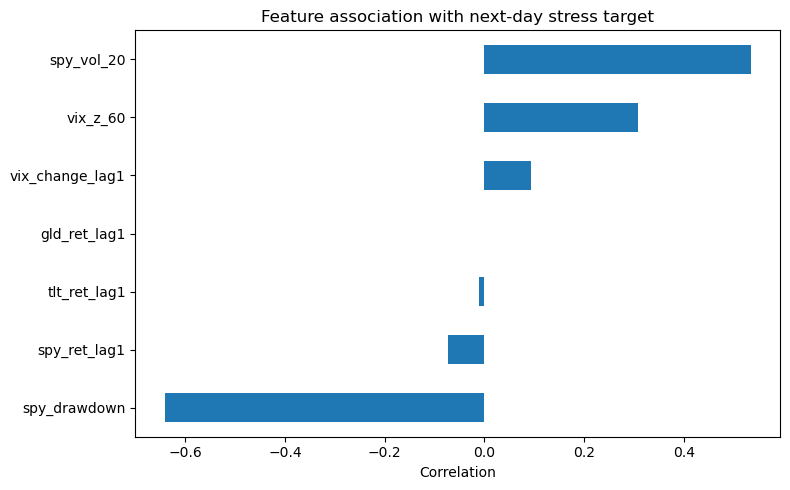

In [5]:
featured=build_market_features(prices).dropna(subset=FEATURES+['target_next_high_stress']).copy(); feature_path=DATA/'processed/market_features.csv'; featured.to_csv(feature_path,index=False); print('Feature table:',featured.shape,feature_path); display(featured[FEATURES+['target_next_high_stress']].head())
corr=featured[FEATURES+['target_next_high_stress']].corr()['target_next_high_stress'].drop('target_next_high_stress').sort_values(); ax=corr.plot.barh(figsize=(8,5)); ax.set(title='Feature association with next-day stress target',xlabel='Correlation'); plt.tight_layout(); plt.show()

## Stage 10: Time-aware classification model
Only one modeling track is required. Logistic regression is chosen for interpretability; the earliest 80% trains the model and the latest 20% tests deployment-like performance.

,chronological_test
accuracy,0.910345
precision,0.447368
recall,0.772727
f1,0.566667


Train end: 2024-10-31 00:00:00 Test start: 2024-11-01 00:00:00


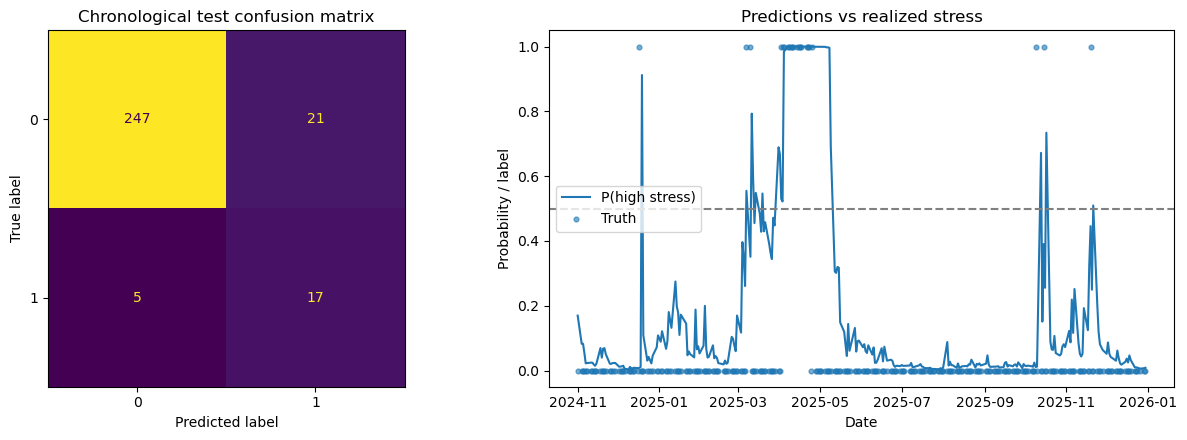

In [6]:
model,train,test=train_time_split(featured,.8); y=test.target_next_high_stress.astype(int); pred=model.predict(test[FEATURES]); prob=model.predict_proba(test[FEATURES])[:,1]; baseline=metrics(y,pred); display(pd.Series(baseline).to_frame('chronological_test')); print('Train end:',train.Date.max(),'Test start:',test.Date.min())
fig,axes=plt.subplots(1,2,figsize=(13,4.5)); ConfusionMatrixDisplay.from_predictions(y,pred,ax=axes[0],colorbar=False); axes[0].set_title('Chronological test confusion matrix'); axes[1].plot(pd.to_datetime(test.Date),prob,label='P(high stress)'); axes[1].scatter(pd.to_datetime(test.Date),y,s=12,label='Truth',alpha=.6); axes[1].axhline(.5,color='gray',ls='--'); axes[1].set(title='Predictions vs realized stress',xlabel='Date',ylabel='Probability / label'); axes[1].legend(); fig.tight_layout(); fig.savefig(IMAGES/'model_evaluation.png',dpi=170); plt.show()

Accuracy can be inflated by rare non-stress days, so recall/F1 and false negatives matter more. The model is predictive, not causal; label thresholds, regime change, time dependence, and proxy mismatch limit trust.

## Stage 11: Bootstrap uncertainty, scenario and subgroup risk

,accuracy,precision,recall,f1
Baseline,0.910345,0.447368,0.772727,0.566667
Class-balanced,0.851724,0.327869,0.909091,0.481928


Baseline accuracy bootstrap 95% CI: (0.876, 0.941)


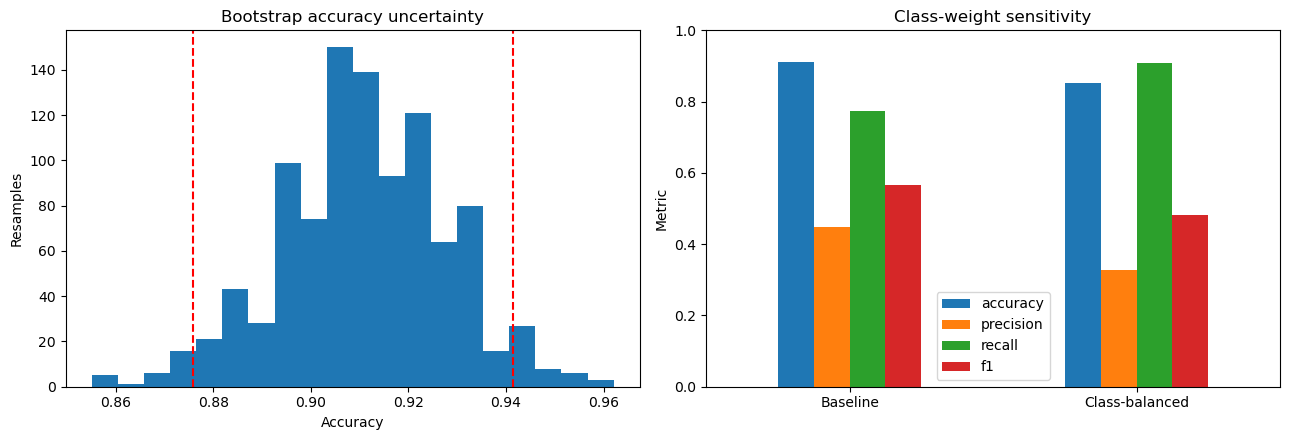

,accuracy,precision,recall,f1
regime,,,,
Lower volatility,0.958621,0.000000,0.000000,0.00000
Higher volatility,0.862069,0.485714,0.894737,0.62963


In [7]:
boot,ci=bootstrap_accuracy(y,pred,1000,5040); balanced,_,test2=train_time_split(featured,.8,class_weight='balanced'); pred2=balanced.predict(test2[FEATURES]); alternate=metrics(test2.target_next_high_stress.astype(int),pred2); scenario=pd.DataFrame({'Baseline':baseline,'Class-balanced':alternate}).T; display(scenario); print('Baseline accuracy bootstrap 95% CI:',tuple(round(x,3) for x in ci))
fig,axes=plt.subplots(1,2,figsize=(13,4.5)); axes[0].hist(boot,bins=20); axes[0].axvline(ci[0],color='red',ls='--'); axes[0].axvline(ci[1],color='red',ls='--'); axes[0].set(title='Bootstrap accuracy uncertainty',xlabel='Accuracy',ylabel='Resamples'); scenario.plot.bar(ax=axes[1]); axes[1].set(title='Class-weight sensitivity',ylabel='Metric',ylim=(0,1)); axes[1].tick_params(axis='x',rotation=0); fig.tight_layout(); fig.savefig(IMAGES/'uncertainty_scenarios.png',dpi=170); plt.show()
sub=test.copy(); sub['pred']=pred; sub['regime']=pd.qcut(sub.spy_vol_20,2,labels=['Lower volatility','Higher volatility']); subgroup=sub.groupby('regime',observed=True).apply(lambda g:pd.Series(metrics(g.target_next_high_stress.astype(int),g.pred)),include_groups=False); display(subgroup)

The bootstrap interval communicates sampling uncertainty but assumes exchangeable observations and may be optimistic for time series. The class-balanced scenario exposes the precision/recall tradeoff. Volatility subgroup gaps identify monitoring needs, not proven structural differences.

## Stages 12–13: Deliver, save and test the product

In [8]:
bundle_path=save_bundle(model,P/'model/market_stress_model.pkl'); loaded=joblib.load(bundle_path); assert loaded['features']==FEATURES; np.testing.assert_allclose(loaded['model'].predict_proba(test[FEATURES].iloc[:3]),model.predict_proba(test[FEATURES].iloc[:3])); print('Saved and reload-verified:',bundle_path)
report=f'''# Multi-Asset Market Stress — Stakeholder Report

## Executive summary
- The model is an interpretable review trigger, not a trading system.
- Chronological test accuracy is {baseline['accuracy']:.1%}, recall is {baseline['recall']:.1%}, with bootstrap accuracy CI {ci[0]:.1%}–{ci[1]:.1%}.
- Class balancing changes recall from {baseline['recall']:.1%} to {alternate['recall']:.1%}; the operating threshold must reflect the cost of missed stress.

![Model evaluation](images/model_evaluation.png)
![Uncertainty and scenarios](images/uncertainty_scenarios.png)

## Assumptions and risks
Past SPY/VIX/TLT/GLD relationships are assumed informative, inputs timely, and VIX≥25 or SPY≤−2.5% a useful stress definition. Regime drift, rare events, time dependence, data revisions, and mismatch with the actual portfolio can invalidate results.

## Decision implication
Use the score to trigger analyst review. Do not change allocation automatically. Extend walk-forward validation, calibrate probabilities, incorporate portfolio loss and transaction costs, and monitor freshness, drift, recall, latency and alert volume before production.
'''
REPORTS.mkdir(exist_ok=True); (REPORTS/'stakeholder_report.md').write_text(report); print('Saved stakeholder report')

Saved and reload-verified: /Users/zhanyadan/Desktop/bootcamp_Yadan_Zhan/project/model/market_stress_model.pkl
Saved stakeholder report


In [9]:
sample={name:float(test.iloc[-1][name]) for name in FEATURES}; server=subprocess.Popen([sys.executable,'app.py'],cwd=P,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True)
for _ in range(40):
 try:
  health=requests.get('http://127.0.0.1:5051/health',timeout=.25); break
 except requests.RequestException: time.sleep(.25)
else: server.terminate(); raise RuntimeError('API failed to start')
ok=requests.post('http://127.0.0.1:5051/predict',json={'features':sample},timeout=3); bad=requests.post('http://127.0.0.1:5051/predict',json={'features':{}},timeout=3)
print('HEALTH',health.status_code,health.json()); print('PREDICT',ok.status_code,ok.json()); print('BAD',bad.status_code,bad.json()); assert health.status_code==ok.status_code==200 and bad.status_code==400
server.terminate(); server.wait(timeout=5); print('API smoke test complete; server stopped.')

HEALTH 200 {'feature_count': 7, 'model': 'market_stress_classifier', 'status': 'ok'}
PREDICT 200 {'high_stress_flag': 0, 'high_stress_probability': 0.008545593142698944}
BAD 400 {'error': "missing features: ['spy_ret_lag1', 'vix_change_lag1', 'spy_vol_20', 'spy_drawdown', 'vix_z_60', 'tlt_ret_lag1', 'gld_ret_lag1']"}
API smoke test complete; server stopped.


## Lifecycle conclusion
The project now connects immutable data, cleaning, explicit outlier assumptions, EDA, past-only features, chronological modeling, uncertainty/scenario evaluation, stakeholder delivery, a saved API-served model, monitoring ownership, orchestration, and final lifecycle documentation. Human approval remains the final control.